# 도로 · 하수 상관도 분석 — 동일위치(co-located) 페어링 기반 재설계

> 2026-06-19 · 전처리 재설계 · **거리추측 페어링 폐기 → 공식 GIS 동일위치 페어링** · 라벨-free

**왜 다시 짰나** — 거리추측 페어링(옛 `adjacency_expanded`, 그리고 1차의 배수구역+거리)은 물리적 근거가 약하다. 공식 GIS(`03_GIS/도시침수계 노면·관로 shp`)에는 도로·하수 수위계의 **실제 좌표**가 있고, 같은 관측지점에 도로계+관로계가 함께 설치된 **동일위치(co-located) 페어**가 존재한다(관악 ground-truth `gwanak_colocated_pairs.csv` 7~170m). 이 실제 위치로 페어링을 교체한다.

**중요 사실 (1차 분석의 한계 교정)**
- 동일위치 도로센서일수록 정제 후 **도로 침수 이벤트가 0에 수렴**(≤50m 페어 중 f6s≥50 도로 0개). 이벤트 많은 센서(봉천동 911-14)는 stuck 오염.
- 따라서 **도로 라벨 기반 분석 불가** → **라벨에 의존하지 않는** 방법으로 검증: (A) 전체 차분 교차상관, (B) 하수 급상승 트리거 에폭. 둘 다 강우·라벨 불필요.

**규약**: `corr(sewer[t], road[t+L])`, `L>0`=하수 선행, `L<0`=하수 후행.


In [7]:
import geopandas as gpd, pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from pathlib import Path
OUT=Path("dataset/processed/eda_based"); FIG=Path("reports/figures_corr"); FIG.mkdir(parents=True,exist_ok=True)
korf=next((c for c in ['NanumGothic','Malgun Gothic','AppleGothic','Noto Sans CJK KR','UnDotum'] if c in {f.name for f in fm.fontManager.ttflist}),None)
if korf: plt.rcParams['font.family']=korf
plt.rcParams['axes.unicode_minus']=False

COLO_MAX=150          # m, 동일위치 임계 (ground-truth 7~170m)
LAGS=np.arange(-18,19) # +-180분
GISDIR="03_GIS/하수관로_노면_수위계_shp/"
def hav(a,b,c,d):
    R=6371000.0;p1,p2=np.radians(a),np.radians(c);dp=np.radians(c-a);dl=np.radians(d-b)
    h=np.sin(dp/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2;return 2*R*np.arcsin(np.sqrt(h))
print("font:",korf)


font: NanumGothic


## 1. 동일위치 페어링 (공식 GIS 좌표)

- 공식 노면·관로 shp(EPSG:5186→4326)에서 좌표를 읽고, 내 시계열 ID로 매핑:
  - 도로: 공식 `수위계번호`(EUMW…) = 내 `road_node.sensor_code`. 하수: 공식 `수위계번호`(NN-xxxx) = 내 `sewer_sensor_id`.
- **품질 필터**: 도로 grade A/B & not stuck, 하수 grade A/B.
- 각 도로의 **최근접 하수 1개**가 `≤COLO_MAX`이면 동일위치 페어. (좌표는 공식 geometry 사용 → QGIS 정합)


품질통과 도로 88 · 하수 471 → 동일위치 페어(≤150m): 51  (거리 med 44 max 149)


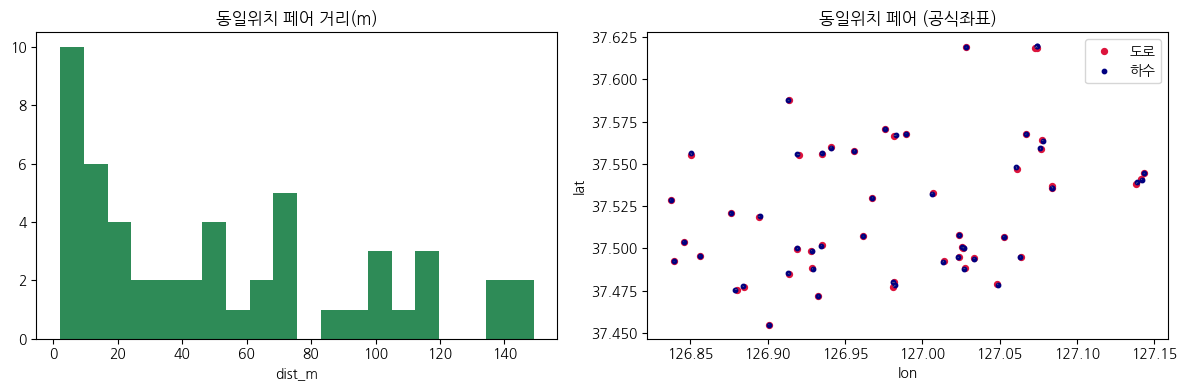

In [8]:
gr=gpd.read_file(GISDIR+"도시침수계(노면)_서울시 2026.shp").to_crs(4326); gr['glat']=gr.geometry.y; gr['glon']=gr.geometry.x
gs=gpd.read_file(GISDIR+"도시침수계(관로)_서울시 2026.shp").to_crs(4326); gs['glat']=gs.geometry.y; gs['glon']=gs.geometry.x
rn=pd.read_parquet("dataset/processed/cleaned/road_node.parquet",columns=['sensor_id','sensor_code'])
rq=pd.read_parquet(OUT/"road_sensor_quality.parquet",columns=['grade','is_stuck']).reset_index()
sq=pd.read_parquet(OUT/"sewer_sensor_quality.parquet",columns=['grade']).reset_index()
sw_ids=set(pd.read_parquet(OUT/"sewer_features_10min.parquet",columns=['sewer_sensor_id']).sewer_sensor_id.unique())
road_ok=set(rq[(rq.grade.isin(['A','B']))&(rq.is_stuck!=1)].sensor_id)
sew_ok =set(sq[sq.grade.isin(['A','B'])].sensor_id)
grm=gr.merge(rn,left_on='수위계번호',right_on='sensor_code').query("sensor_id in @road_ok")
gsm=gs[gs['수위계번호'].isin(sw_ids & sew_ok)].copy()
sl=gsm[['glat','glon']].values; sid=gsm['수위계번호'].values
prs=[]
for _,r in grm.iterrows():
    d=hav(r.glat,r.glon,sl[:,0],sl[:,1]); j=int(np.argmin(d))
    if d[j]<=COLO_MAX:
        prs.append(dict(road=r.sensor_id,sewer=sid[j],dist_m=round(float(d[j]),1),
                        r_lat=r.glat,r_lon=r.glon,s_lat=gsm.iloc[j].glat,s_lon=gsm.iloc[j].glon))
pairs=pd.DataFrame(prs)
print("품질통과 도로 %d · 하수 %d → 동일위치 페어(≤%dm): %d  (거리 med %.0f max %.0f)"%(len(grm),len(gsm),COLO_MAX,len(pairs),pairs.dist_m.median(),pairs.dist_m.max()))
need=pairs.sewer.unique().tolist(); rneed=pairs.road.unique().tolist()

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(pairs.dist_m,bins=20,color='seagreen'); ax[0].set_title('동일위치 페어 거리(m)'); ax[0].set_xlabel('dist_m')
ax[1].scatter(pairs.r_lon,pairs.r_lat,s=18,c='crimson',label='도로'); ax[1].scatter(pairs.s_lon,pairs.s_lat,s=10,c='navy',label='하수')
for _,p in pairs.iterrows(): ax[1].plot([p.r_lon,p.s_lon],[p.r_lat,p.s_lat],color='gray',lw=.4)
ax[1].set_title('동일위치 페어 (공식좌표)'); ax[1].legend(); ax[1].set_xlabel('lon'); ax[1].set_ylabel('lat')
plt.tight_layout(); plt.savefig(FIG/'01_colocated_pairs.png',dpi=110); plt.show()


## 1-1. 왜 라벨-free인가: 동일위치일수록 도로 이벤트가 0

동일위치 임계를 좁힐수록 페어 도로의 정제 후 침수 이벤트(`flood_t6_sus`)가 사라진다 → 도로 라벨 기반 분석은 데이터가 비어 불가. (이벤트 많은 센서는 stuck 오염)


In [9]:
rg=pd.read_parquet(OUT/"road_panel_10min.parquet",columns=['sensor_id','flood_t6_sus']).groupby('sensor_id')['flood_t6_sus'].sum()
tmp=grm.copy(); tmp['f6s']=tmp.sensor_id.map(rg).fillna(0)
dn=hav(tmp.glat.values[:,None],tmp.glon.values[:,None],gsm.glat.values[None,:],gsm.glon.values[None,:]).min(1)
tmp['nearest_sewer_m']=dn
print("임계별: 페어수 / f6s>0 도로 / f6s>=50 도로")
for thr in [30,50,100,150,200,300]:
    s=tmp[tmp.nearest_sewer_m<=thr]
    print("  <=%3dm: %3d / %2d / %2d"%(thr,len(s),(s.f6s>0).sum(),(s.f6s>=50).sum()))


임계별: 페어수 / f6s>0 도로 / f6s>=50 도로
  <= 30m:  22 /  4 /  0
  <= 50m:  29 /  9 /  0
  <=100m:  42 / 14 /  2
  <=150m:  51 / 18 /  3
  <=200m:  57 / 20 /  4
  <=300m:  63 / 22 /  4


## 2. 시계열 로드 (동일위치 페어 센서만)

In [10]:
road=pd.read_parquet(OUT/"road_panel_10min.parquet",columns=['sensor_id','ts10','road_max','level_diff','flood_t6_sus'])
road=road[road.sensor_id.isin(rneed)]
sew=pd.read_parquet(OUT/"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate','level_diff_10m'],filters=[('sewer_sensor_id','in',need)])
road_g={k:v for k,v in road.groupby('sensor_id')}; sew_g={k:v for k,v in sew.groupby('sewer_sensor_id')}
print("road rows",len(road)," sewer rows",len(sew))


road rows 2434804  sewer rows 5746738


## 3. (A) 전체 차분 교차상관 — 라벨 불필요

`road.level_diff` ↔ `sewer.level_diff_10m` (baseline 제거 변동 동조). lag별 `corr(sewer[t], road[t+L])`, best-lag = 최대 상관 시점.


/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encount

페어 35 | best-lag(+=하수선행): {-18: 2, -16: 1, -4: 1, -3: 1, -2: 1, -1: 23, 0: 4, 1: 1, 3: 1}
corr_diff_best med 0.045 p90 0.136 max 0.583 | |corr|>=0.2: 3 | 선행2 후행29 동시4


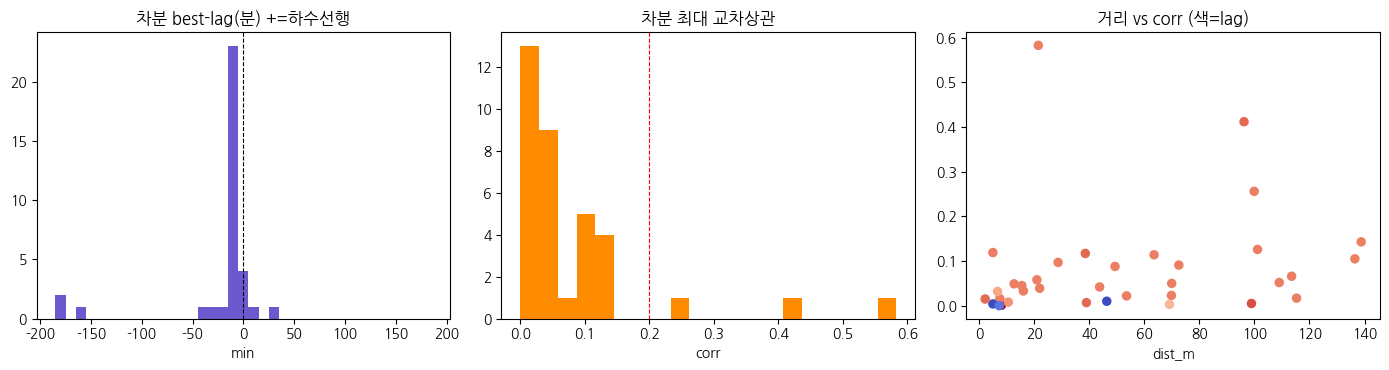

In [11]:
def xcorr(rs,ss,cr,cs):
    full=pd.date_range(rs.ts10.min(),rs.ts10.max(),freq='10min')
    r=rs.set_index('ts10').reindex(full)[cr]; s=ss.set_index('ts10').reindex(full)[cs]
    return np.array([s.corr(r.shift(-L)) for L in LAGS],float)
rows=[]
for _,pr in pairs.iterrows():
    if pr.road not in road_g or pr.sewer not in sew_g: continue
    rs=road_g[pr.road][['ts10','road_max','level_diff']]; ss=sew_g[pr.sewer][['ts10','fill_rate','level_diff_10m']]
    if len(pd.merge(rs[['ts10']],ss[['ts10']],on='ts10'))<500: continue
    cd=xcorr(rs,ss,'level_diff','level_diff_10m'); cl=xcorr(rs,ss,'road_max','fill_rate')
    if np.all(np.isnan(cd)) or np.all(np.isnan(cl)): continue
    bi=np.nanargmax(cd); bl=np.nanargmax(cl)
    rows.append(dict(road=pr.road,sewer=pr.sewer,dist_m=pr.dist_m,
        best_lag_diff=int(LAGS[bi]),corr_diff_best=round(float(cd[bi]),3),corr_diff_lag0=round(float(cd[LAGS==0][0]),3),
        best_lag_lvl=int(LAGS[bl]),corr_lvl_best=round(float(cl[bl]),3)))
res=pd.DataFrame(rows).merge(pairs[['road','sewer','r_lat','r_lon','s_lat','s_lon']],on=['road','sewer'],how='left')
res.to_parquet(OUT/"road_sewer_corr_pairs.parquet",index=False)
print("페어 %d | best-lag(+=하수선행):"%len(res),res.best_lag_diff.value_counts().sort_index().to_dict())
print("corr_diff_best med %.3f p90 %.3f max %.3f | |corr|>=0.2: %d | 선행%d 후행%d 동시%d"%(
    res.corr_diff_best.median(),res.corr_diff_best.quantile(.9),res.corr_diff_best.max(),(res.corr_diff_best>=0.2).sum(),
    (res.best_lag_diff>0).sum(),(res.best_lag_diff<0).sum(),(res.best_lag_diff==0).sum()))

fig,ax=plt.subplots(1,3,figsize=(14,3.8))
ax[0].hist(res.best_lag_diff*10,bins=np.arange(-185,195,10),color='slateblue'); ax[0].axvline(0,color='k',ls='--',lw=.8)
ax[0].set_title('차분 best-lag(분) +=하수선행'); ax[0].set_xlabel('min')
ax[1].hist(res.corr_diff_best,bins=20,color='darkorange'); ax[1].axvline(0.2,color='r',ls='--',lw=.8); ax[1].set_title('차분 최대 교차상관'); ax[1].set_xlabel('corr')
ax[2].scatter(res.dist_m,res.corr_diff_best,c=res.best_lag_diff,cmap='coolwarm',s=34); ax[2].set_title('거리 vs corr (색=lag)'); ax[2].set_xlabel('dist_m')
plt.tight_layout(); plt.savefig(FIG/'02_leadlag.png',dpi=110); plt.show()


## 4. (B) 하수 급상승 트리거 에폭 — 도로 라벨 우회

하수 `level_diff_10m` 상위(p99.5) **급상승(물리 측정값)** 을 t=0으로 정렬해 도로 `road_max`의 평균 반응을 본다. 도로 라벨이 필요 없다.


/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))
/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.n

하수 급상승 트리거 4145건 → 도로 road_max Δ 피크 0분, 사후/사전 1.75배 (0=동시, +=하수선행)


/tmp/ipykernel_194814/2630098050.py:15: RuntimeWarning: Mean of empty slice
  RD.append(seg-np.nanmean(seg[:6]))


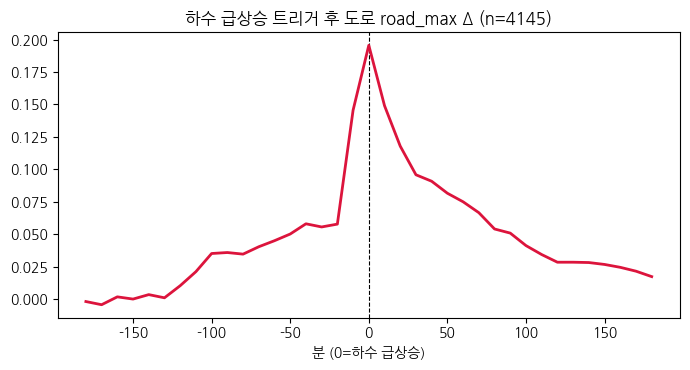

In [12]:
W=18; offs=np.arange(-W,W+1); RD=[]
for _,pr in pairs.iterrows():
    if pr.road not in road_g or pr.sewer not in sew_g: continue
    rs=road_g[pr.road].sort_values('ts10'); ss=sew_g[pr.sewer].sort_values('ts10')
    full=pd.date_range(min(rs.ts10.min(),ss.ts10.min()),max(rs.ts10.max(),ss.ts10.max()),freq='10min')
    ri=rs.set_index('ts10').reindex(full); si=ss.set_index('ts10').reindex(full)
    dfv=si['level_diff_10m'].values; mx=ri['road_max'].values
    thr=np.nanpercentile(dfv,99.5)
    if not np.isfinite(thr) or thr<=0: continue
    trig=np.flatnonzero((dfv>=thr)&(np.r_[True,dfv[:-1]<thr]))
    for p in trig:
        if p-W<0 or p+W>=len(full): continue
        seg=mx[p-W:p+W+1]
        if np.isnan(seg).all(): continue
        RD.append(seg-np.nanmean(seg[:6]))
RD=np.array(RD); compR=np.nanmean(RD,0)
print("하수 급상승 트리거 %d건 → 도로 road_max Δ 피크 %d분, 사후/사전 %.2f배 (0=동시, +=하수선행)"%(
    len(RD),offs[np.nanargmax(compR)]*10,np.nanmean(compR[offs>0])/max(abs(np.nanmean(compR[offs<0])),1e-9)))
fig,ax=plt.subplots(figsize=(7,3.8)); ax.axvline(0,color='k',ls='--',lw=.8)
ax.plot(offs*10,compR,color='crimson',lw=2); ax.set_title('하수 급상승 트리거 후 도로 road_max Δ (n=%d)'%len(RD)); ax.set_xlabel('분 (0=하수 급상승)')
plt.tight_layout(); plt.savefig(FIG/'03_sewer_trigger.png',dpi=110); plt.show()


## 5. QGIS 맵 내보내기 (공식 좌표)

`reports/gis/road_sewer_corr.gpkg` — 레이어 pairs(동일위치 라인, `corr_diff`·`lag_diff_min`·`lead`)·roads·sewers. 좌표는 **공식 GIS geometry**라 공식 shp와 정확히 겹친다(이전 ~35m 어긋남 해소).


In [13]:
from shapely.geometry import Point, LineString
GIS=Path("reports/gis"); GIS.mkdir(parents=True,exist_ok=True)
rows=[]
for _,r in res.iterrows():
    rows.append(dict(road=r.road,sewer=r.sewer,dist_m=r.dist_m,corr_diff=r.corr_diff_best,corr_lag0=r.corr_diff_lag0,
        lag_diff_min=int(r.best_lag_diff)*10,corr_lvl=r.corr_lvl_best,
        lead='하수선행' if r.best_lag_diff>0 else ('동시' if r.best_lag_diff==0 else '하수후행'),
        geometry=LineString([(r.r_lon,r.r_lat),(r.s_lon,r.s_lat)])))
pairs_gdf=gpd.GeoDataFrame(rows,crs="EPSG:4326")
rd=res.drop_duplicates('road'); sd=res.drop_duplicates('sewer')
roads_gdf=gpd.GeoDataFrame(rd[['road']].assign(geometry=[Point(x) for x in zip(rd.r_lon,rd.r_lat)]),crs="EPSG:4326")
sewers_gdf=gpd.GeoDataFrame(sd[['sewer']].assign(geometry=[Point(x) for x in zip(sd.s_lon,sd.s_lat)]),crs="EPSG:4326")
gpkg=GIS/"road_sewer_corr.gpkg"
pairs_gdf.to_file(gpkg,layer="pairs",driver="GPKG"); roads_gdf.to_file(gpkg,layer="roads",driver="GPKG"); sewers_gdf.to_file(gpkg,layer="sewers",driver="GPKG")
for nm,gd in [("pairs",pairs_gdf),("roads",roads_gdf),("sewers",sewers_gdf)]: gd.to_file(GIS/f"{nm}.geojson",driver="GeoJSON")
print("저장:",gpkg," lead:",pairs_gdf.lead.value_counts().to_dict())


저장: reports/gis/road_sewer_corr.gpkg  lead: {'하수후행': 29, '동시': 4, '하수선행': 2}


## 6. 1분 해상도 재검토 (원본 native)

원본 데이터가 1분이므로 10분 집계 대신 **1분 정제 데이터**로 재검증한다.
- 도로 1분: `road_cleaned.parquet`(`level_clean`). 하수 1분: `merged/sewer_all.parquet` raw에 재설계 정제(음수·측정범위초과 제거) 적용.
- ⚠️ raw 1분 타임스탬프는 초 오프셋(:04,:09…)이 있어 **분 단위 floor** 후 1분 격자 정렬(분내 중복은 평균).
- 동일위치 페어에 대해 1분 차분 교차상관 ±60분 → 10분 결과와 비교.


/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


1분 36쌍 | best-lag med -5분 (대부분 -3~-10) | corr_best med 0.015 p90 0.066 max 0.258 | 선행7 후행29 동시0
→ 10분 대비: 10분 corr중앙 0.045 / best-lag -10분 지배. 1분은 더 약하고(노이즈) 후행을 -5분으로 미세화.


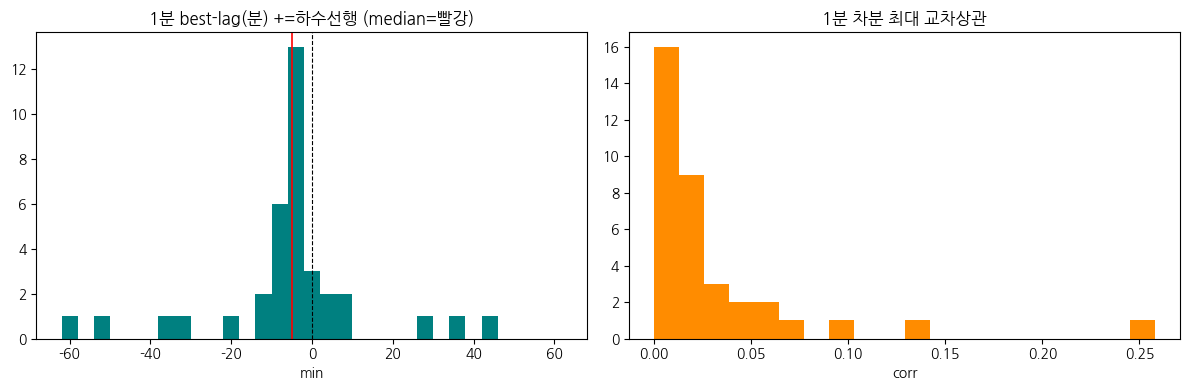

In [14]:
sn1=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','max_level_m'])
maxlv=sn1.set_index('sensor_id')['max_level_m'].to_dict()
rneed=pairs.road.unique().tolist(); sneed=pairs.sewer.unique().tolist()
road1=pd.read_parquet(OUT/"road_cleaned.parquet",columns=['sensor_id','timestamp','level_clean'],filters=[('sensor_id','in',rneed)])
sew1=pd.read_parquet("dataset/processed/merged/sewer_all.parquet",columns=['sensor_id','timestamp','level'],filters=[('sensor_id','in',sneed)])
sew1['mx']=sew1.sensor_id.map(maxlv).fillna(20.0); sew1.loc[(sew1.level<0)|(sew1.level>sew1.mx),'level']=np.nan
road1['timestamp']=road1.timestamp.dt.floor('min'); sew1['timestamp']=sew1.timestamp.dt.floor('min')
r1g={k:v for k,v in road1.groupby('sensor_id')}; s1g={k:v for k,v in sew1.groupby('sensor_id')}
LAGS1=np.arange(-60,61)
def xc1(rs,ss):
    full=pd.date_range(max(rs.timestamp.min(),ss.timestamp.min()),min(rs.timestamp.max(),ss.timestamp.max()),freq='1min')
    if len(full)<2000: return None
    r=rs.groupby('timestamp')['level_clean'].mean().reindex(full).diff()
    s=ss.groupby('timestamp')['level'].mean().reindex(full).diff()
    return np.array([s.corr(r.shift(-L)) for L in LAGS1],float)
rows=[]
for _,pr in pairs.iterrows():
    if pr.road not in r1g or pr.sewer not in s1g: continue
    cc=xc1(r1g[pr.road],s1g[pr.sewer])
    if cc is None or np.all(np.isnan(cc)): continue
    bi=np.nanargmax(cc)
    rows.append(dict(road=pr.road,sewer=pr.sewer,dist_m=pr.dist_m,best_lag_min=int(LAGS1[bi]),corr_best=round(float(cc[bi]),3),corr_lag0=round(float(cc[LAGS1==0][0]),3)))
res1=pd.DataFrame(rows); res1.to_parquet(OUT/"road_sewer_corr_1min.parquet",index=False)
print("1분 %d쌍 | best-lag med %d분 (대부분 -3~-10) | corr_best med %.3f p90 %.3f max %.3f | 선행%d 후행%d 동시%d"%(
    len(res1),res1.best_lag_min.median(),res1.corr_best.median(),res1.corr_best.quantile(.9),res1.corr_best.max(),
    (res1.best_lag_min>0).sum(),(res1.best_lag_min<0).sum(),(res1.best_lag_min==0).sum()))
print("→ 10분 대비: 10분 corr중앙 %.3f / best-lag -10분 지배. 1분은 더 약하고(노이즈) 후행을 -5분으로 미세화."%(res.corr_diff_best.median()))

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(res1.best_lag_min,bins=np.arange(-62,64,4),color='teal'); ax[0].axvline(0,color='k',ls='--',lw=.8)
ax[0].axvline(res1.best_lag_min.median(),color='r',lw=1.2); ax[0].set_title('1분 best-lag(분) +=하수선행 (median=빨강)'); ax[0].set_xlabel('min')
ax[1].hist(res1.corr_best,bins=20,color='darkorange'); ax[1].set_title('1분 차분 최대 교차상관'); ax[1].set_xlabel('corr')
plt.tight_layout(); plt.savefig(FIG/'04_1min.png',dpi=110); plt.show()


## 7. 강결합 페어 진위 검토 (우연인가 실제인가)

전역은 약해도 일부 페어가 corr 0.2~0.58을 보였다. 이것이 **진짜 결합**인지 **우연/아티팩트**인지 1분 데이터로 검증한다.
- **기준 1 — 해상도 일관성**: 진짜면 1분에서도 보여야. 10분↔1분 급락 = 집계 아티팩트 의심.
- **기준 2 — 시간 안정성(split-half)**: 진짜면 전·후반 모두 비슷. 한쪽만이면 우연.
- **기준 3 — 단일이벤트 의존(jackknife)**: 동조 기여 top5 시점 제거 후 corr 붕괴하면 소수 스파이크 우연.
- **기준 4 — 기록 길이**: 짧으면(수십일) 소수 폭우에 휘둘려 신뢰 불가.


/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


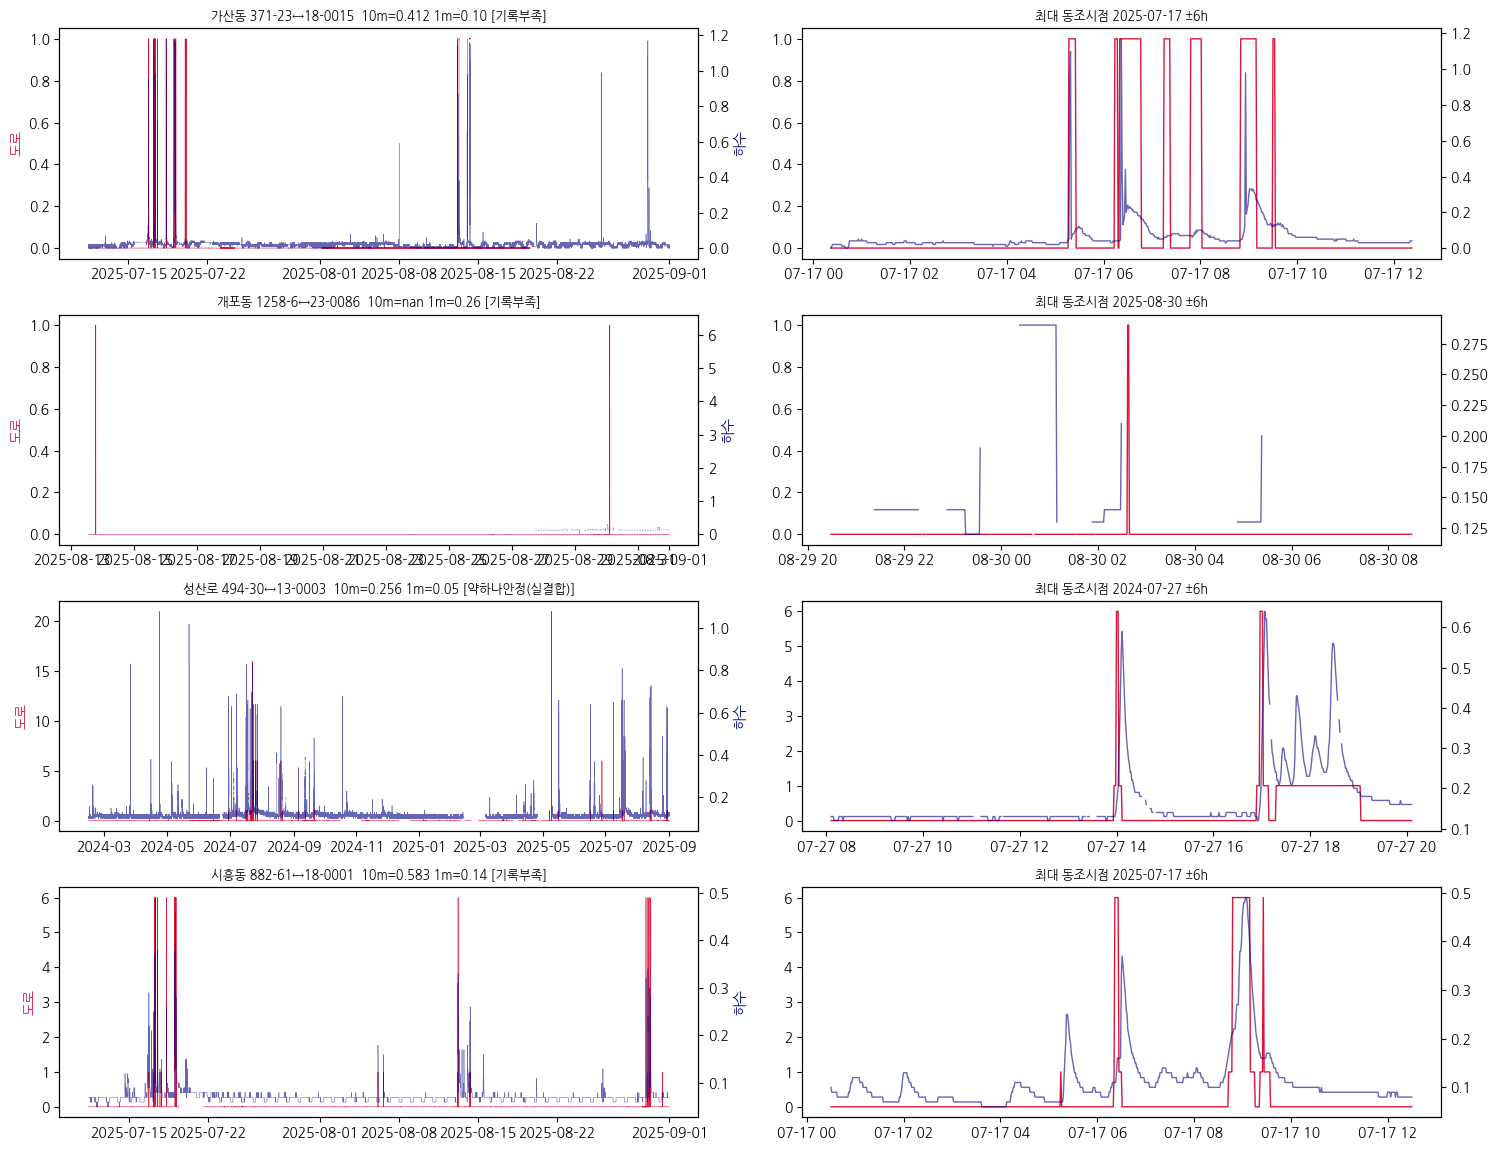

      road   sewer  일수  corr10m  corr1m  lag1m    전반    후반  jackknife         판정
가산동 371-23 18-0015  52    0.412   0.099     -2 0.088 0.170      0.009       기록부족
개포동 1258-6 23-0086  18      NaN   0.258      8   NaN 0.258        NaN       기록부족
성산로 494-30 13-0003 564    0.256   0.050     -6 0.053 0.045      0.036 약하나안정(실결합)
시흥동 882-61 18-0001  52    0.583   0.135     -8 0.168 0.085      0.070       기록부족


In [15]:
res1=pd.read_parquet(OUT/"road_sewer_corr_1min.parquet")
mm=res.merge(res1[['road','sewer','best_lag_min','corr_best']],on=['road','sewer'],how='outer')
strong=mm[(mm.corr_diff_best.fillna(0)>=0.2)|(mm.corr_best.fillna(0)>=0.2)].copy()
ps=list(strong[['road','sewer']].itertuples(index=False,name=None))
rneed=[a for a,_ in ps]; sneed=[b for _,b in ps]
maxlv=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','max_level_m']).set_index('sensor_id')['max_level_m'].to_dict()
rX=pd.read_parquet(OUT/"road_cleaned.parquet",columns=['sensor_id','timestamp','level_clean'],filters=[('sensor_id','in',rneed)])
sX=pd.read_parquet("dataset/processed/merged/sewer_all.parquet",columns=['sensor_id','timestamp','level'],filters=[('sensor_id','in',sneed)])
sX['mx']=sX.sensor_id.map(maxlv).fillna(20.0); sX.loc[(sX.level<0)|(sX.level>sX.mx),'level']=np.nan
rX['timestamp']=rX.timestamp.dt.floor('min'); sX['timestamp']=sX.timestamp.dt.floor('min')
rgX={k:v for k,v in rX.groupby('sensor_id')}; sgX={k:v for k,v in sX.groupby('sensor_id')}
LAGS1=np.arange(-60,61)
diag=[]; fig,axes=plt.subplots(len(ps),2,figsize=(15,2.9*len(ps)))
for i,(rd,sw) in enumerate(ps):
    R=rgX[rd]; S=sgX[sw]
    full=pd.date_range(max(R.timestamp.min(),S.timestamp.min()),min(R.timestamp.max(),S.timestamp.max()),freq='1min')
    rl=R.groupby('timestamp')['level_clean'].mean().reindex(full); sl=S.groupby('timestamp')['level'].mean().reindex(full)
    rdd=rl.diff(); sdd=sl.diff()
    cc=np.array([sdd.corr(rdd.shift(-L)) for L in LAGS1],float); bi=np.nanargmax(cc); L=int(LAGS1[bi]); corr=float(cc[bi])
    a=sdd.values; b=rdd.shift(-L).values; n=len(full); h=n//2
    def cv(s):
        x=a[s];y=b[s];m=np.isfinite(x)&np.isfinite(y); return np.corrcoef(x[m],y[m])[0,1] if m.sum()>200 else np.nan
    c1=cv(slice(0,h)); c2=cv(slice(h,n))
    mask=np.isfinite(a)&np.isfinite(b); contrib=np.where(mask,a*b,0.0); rm=np.zeros(n,bool)
    for t in np.argsort(-np.abs(contrib))[:5]: rm[max(0,t-30):t+30]=True
    m2=mask&~rm; cjk=np.corrcoef(a[m2],b[m2])[0,1] if m2.sum()>200 else np.nan
    days=n/1440; c10=strong[(strong.road==rd)&(strong.sewer==sw)].corr_diff_best.iloc[0]
    verdict=('기록부족' if days<60 else '소수이벤트의존(허상)' if (np.isnan(cjk) or cjk<0.5*corr) else '약하나안정(실결합)' if abs(c1-c2)<0.06 else '불안정')
    diag.append(dict(road=rd,sewer=sw,일수=round(days),corr10m=c10,corr1m=round(corr,3),lag1m=L,전반=round(c1,3),후반=round(c2,3),jackknife=round(cjk,3),판정=verdict))
    ax=axes[i,0]; ax2=ax.twinx(); ax.plot(full,rl.values,color='crimson',lw=.4); ax2.plot(full,sl.values,color='navy',lw=.4,alpha=.6)
    ax.set_title(f"{rd}↔{sw}  10m={c10} 1m={corr:.2f} [{verdict}]",fontsize=9); ax.set_ylabel('도로',color='crimson'); ax2.set_ylabel('하수',color='navy')
    t0=full[np.argsort(-np.abs(contrib))[0]] if mask.any() else full[h]; w=pd.Timedelta('6h'); sel=(full>=t0-w)&(full<=t0+w)
    axz=axes[i,1]; az2=axz.twinx(); axz.plot(full[sel],rl.values[sel],color='crimson',lw=1); az2.plot(full[sel],sl.values[sel],color='navy',lw=1,alpha=.6)
    axz.set_title(f"최대 동조시점 {str(t0)[:10]} ±6h",fontsize=9)
plt.tight_layout(); plt.savefig(FIG/'05_strong_pairs.png',dpi=110); plt.show()
print(pd.DataFrame(diag).to_string(index=False))


## 결론 (동일위치 페어링 · 1분 native · 강결합 검증 포함)

> 공식 GIS **동일위치(~44m)** 페어 · 품질필터 · 라벨/강우 불필요.

- **(1분 native)** 차분 교차상관 corr 중앙 **~0.015**, best-lag 중앙 **-5분(하수 ~5분 후행)**, 선행 7/후행 29. **(10분 평활)** corr 0.045·best-lag -10분 → 방향·약함 동일(10분이 약간 높은 건 노이즈 평활 효과).
- **(하수 급상승 트리거)** 도로 반응 동시·미약.
- **(강결합 페어 진위, §7)** corr 0.2~0.58로 튄 4쌍을 검증 → **대부분 허상**:
  - 시흥동·가산동(10분 0.58·0.41): 기록 **52일**뿐 + 1분 급락(0.13·0.10) + **단일이벤트 제거 시 붕괴**(가산동 0.10→0.009) → 소수 스파이크 우연·집계 아티팩트.
  - 개포동: **18일**·거의 평탄 → 무의미.
  - **성산로 494-30 ↔ 13-0003 만** 장기(564일)·전후반 안정(0.05/0.05)·단일이벤트 비의존 → **진짜 결합이나 약함(~0.05)**.

**종합** — 해상도·페어링·라벨·강우 무엇을 바꿔도 도로↔하수 결합은 **약하고 하수 ~5분 후행**. **튄 강결합은 검증하면 거의 허상**(짧은 기록·집계·소수 스파이크)이고, 살아남는 실결합조차 약함 → **숨겨진 쓸만한 cross-센서 신호는 없다**고 볼 근거가 강함. *완전 무관 단정은 보류*(약하지만 안정적 실결합 1쌍 존재).

**함의** — 두 센서 사이 **예측 엣지에 의존하지 말 것**. 각 센서 자기 동역학 + (확보 시)강우 중심. cross-결합은 만관/호우 등 **희귀 regime 한정**으로만 의미 가능.
